<a href="https://colab.research.google.com/github/pprieri/ml/blob/main/Dogs_vs_Cats_Conv2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### This Notebook is part of Kaggle's Dogs vs Cats competition 

### I applied a simple 3 layer Conv2D NN.


**Context**

Asirra (Animal Species Image Recognition for Restricting Access) is a HIP that works by asking users to identify photographs of cats and dogs. This task is difficult for computers, but studies have shown that people can accomplish it quickly and accurately. Many even think it's fun! Here is an example of the Asirra interface:

Asirra is unique because of its partnership with Petfinder.com, the world's largest site devoted to finding homes for homeless pets. They've provided Microsoft Research with over three million images of cats and dogs, manually classified by people at thousands of animal shelters across the United States. Kaggle is fortunate to offer a subset of this data for fun and research. 

Image recognition attacks
While random guessing is the easiest form of attack, various forms of image recognition can allow an attacker to make guesses that are better than random. There is enormous diversity in the photo database (a wide variety of backgrounds, angles, poses, lighting, etc.), making accurate automatic classification difficult. In an informal poll conducted many years ago, computer vision experts posited that a classifier with better than 60% accuracy would be difficult without a major advance in the state of the art. For reference, a 60% classifier improves the guessing probability of a 12-image HIP from 1/4096 to 1/459.

**Content**

The training archive contains 25,000 images of dogs and cats. Train your algorithm on these files and predict the labels for test1.zip (1 = dog, 0 = cat).


More info can be found here: https://www.kaggle.com/c/dogs-vs-cats/data?select=train.zip

### Download data

In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  
# Then move kaggle.json into the folder where the API expects to find it.
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 67 bytes


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!kaggle competitions download -c dogs-vs-cats

 99% 540M/543M [00:03<00:00, 145MB/s]
100% 543M/543M [00:03<00:00, 143MB/s]
  0% 0.00/86.8k [00:00<?, ?B/s]
100% 86.8k/86.8k [00:00<00:00, 91.1MB/s]
100% 270M/271M [00:01<00:00, 152MB/s]
100% 271M/271M [00:01<00:00, 147MB/s]


### Set-up

In [3]:
import tensorflow as tf
import tensorflow.keras as keras
import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
from os import path, getcwd, chdir
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
# !unzip train.zip
# !unzip test1.zip

In [10]:
list_train_dir = os.listdir("./train")

labels = []

for filename in list_train_dir:
  
  label = filename.split('.')[0]

  if label =='dog':
    labels.append(1)
  else:
    labels.append(0)

[0, 0, 0, 0, 0]

In [13]:
df_train_full = pd.DataFrame({'filename' : list_train_dir, 'label' : labels})
print(df_train_full.shape)
df_train_full.head(3)

(25000, 2)


,filename,label
0,cat.10900.jpg,0
1,cat.7423.jpg,0
2,cat.7563.jpg,0


In [16]:
df_train_full['label'].value_counts()

1    12500
0    12500
Name: label, dtype: int64

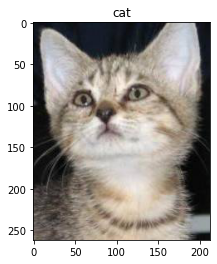

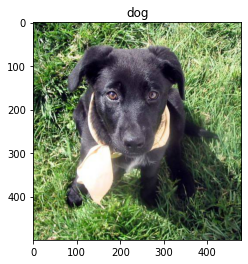

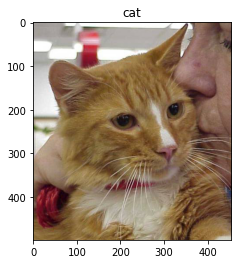

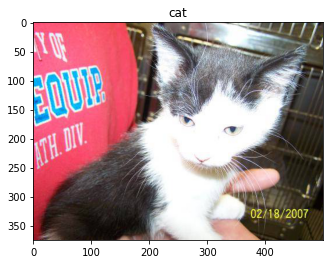

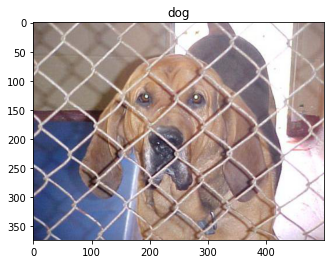

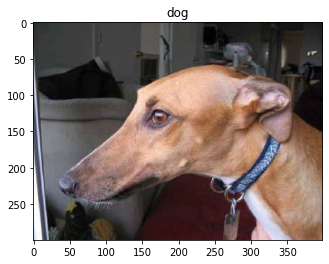

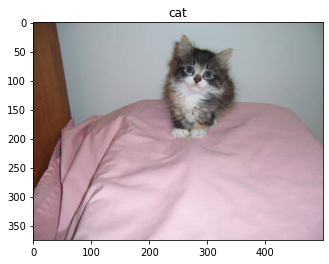

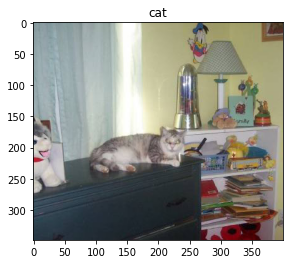

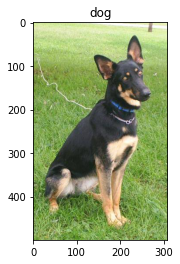

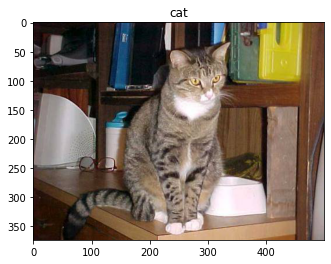

In [36]:
for item in range(10):
  filepath = './train/' + list_train_dir[item+10]
  image = tf.keras.preprocessing.image.load_img(filepath)
  plt.imshow(image)
  plt.title('dog' if labels[item+10]==1 else 'cat')
  plt.show()

Data Prep

In [40]:
df_train_full

df_train_full['label'] = df_train_full['label'].map({0 : 'cat', 1 : 'dog'})

Create Validation set

In [42]:
df_train = df_train_full.sample(frac=0.8, random_state=0)
df_valid = df_train_full.drop(df_train.index)

Train Generator

In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   rotation_range=20,
                                   horizontal_flip = True)



train_generator = train_datagen.flow_from_dataframe(df_train,
                                                    './train/',
                                                    x_col = 'filename',
                                                    y_col = 'label',
                                                    target_size=(128,128),
                                                    batch_size=32,
                                                    class_mode='binary')

Found 20000 validated image filenames belonging to 2 classes.


Valid Generator

In [45]:
valid_datagen = ImageDataGenerator(rescale=1./255)

valid_generator = valid_datagen.flow_from_dataframe(df_valid,
                                                    './train/',
                                                    x_col = 'filename',
                                                    y_col = 'label',
                                                    target_size=(128,128),
                                                    batch_size=32,
                                                    class_mode='binary')

Found 5000 validated image filenames belonging to 2 classes.


## Convolutional NN

In [48]:
batch_size=32

steps_train = int(df_train.shape[0]/batch_size)
steps_valid = int(df_valid.shape[0]/batch_size)

In [49]:
earlystop = keras.callbacks.EarlyStopping(patience=10)
learning_rate_reduction = keras.callbacks.ReduceLROnPlateau(monitor='val_acc', 
                                            patience=2, 
                                            verbose=1, 
                                            factor=0.5, 
                                            min_lr=0.00001)
callbacks = [earlystop, learning_rate_reduction]

In [57]:
model = keras.models.Sequential([
                                 keras.layers.Conv2D(16,(3,3),activation='relu', input_shape=[128,128,3]),
                                 keras.layers.MaxPooling2D(2),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),

                                 keras.layers.Conv2D(32,(3,3),activation='relu'),
                                 keras.layers.MaxPooling2D(2),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),

                                 keras.layers.Conv2D(64,(3,3),activation='relu'),
                                 keras.layers.MaxPooling2D(2),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),

                                 keras.layers.Conv2D(128,(3,3),activation='relu'),
                                 keras.layers.MaxPooling2D(2),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),

                                 keras.layers.Flatten(),

                                 keras.layers.Dense(300, activation='relu'),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15), 

                                 keras.layers.Dense(100, activation='relu'),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),

                                 keras.layers.Dense(1, activation='sigmoid')])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

epochs=30

history = model.fit(train_generator,
                    epochs=epochs,
                    steps_per_epoch=steps_train,
                    validation_data=valid_generator,
                    validation_steps=steps_valid,
                    callbacks=[callbacks],
                    verbose=2)

Epoch 1/30
625/625 - 174s - loss: 0.6298 - accuracy: 0.6650 - val_loss: 0.8059 - val_accuracy: 0.6228
Epoch 2/30
625/625 - 150s - loss: 0.5069 - accuracy: 0.7517 - val_loss: 0.4211 - val_accuracy: 0.8025
Epoch 3/30
625/625 - 144s - loss: 0.4482 - accuracy: 0.7900 - val_loss: 0.4107 - val_accuracy: 0.8167
Epoch 4/30
625/625 - 142s - loss: 0.4039 - accuracy: 0.8183 - val_loss: 0.3400 - val_accuracy: 0.8570
Epoch 5/30
625/625 - 139s - loss: 0.3731 - accuracy: 0.8296 - val_loss: 0.3829 - val_accuracy: 0.8271
Epoch 6/30
625/625 - 139s - loss: 0.3446 - accuracy: 0.8478 - val_loss: 0.2911 - val_accuracy: 0.8752
Epoch 7/30
625/625 - 141s - loss: 0.3193 - accuracy: 0.8588 - val_loss: 0.3358 - val_accuracy: 0.8506
Epoch 8/30
625/625 - 143s - loss: 0.2988 - accuracy: 0.8719 - val_loss: 0.2642 - val_accuracy: 0.8872
Epoch 9/30
625/625 - 144s - loss: 0.2855 - accuracy: 0.8774 - val_loss: 0.2203 - val_accuracy: 0.9067
Epoch 10/30
625/625 - 144s - loss: 0.2757 - accuracy: 0.8817 - val_loss: 0.3323 - 

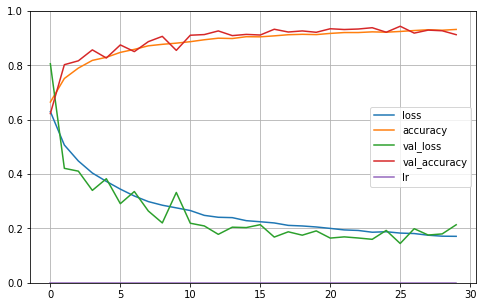

In [58]:

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

Saving parameters


In [60]:
model.save_weights("model.h5")

Prepaing Test Data

In [80]:
list_test_dir = os.listdir('./test1')
df_test = pd.DataFrame({'filename' : list_test_dir})   
print(df_test.shape)
df_test.head(3)

(12500, 1)


,filename
0,1586.jpg
1,4819.jpg
2,10213.jpg


In [81]:
test_data = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
test_generator = test_data.flow_from_dataframe(
    df_test, 
    "./test1/", 
    x_col='filename',
    y_col=None,
    class_mode=None,
    target_size=[128,128],
    batch_size=batch_size,
    shuffle=False)

Found 12500 validated image filenames.


In [82]:
preds = np.argmax(model.predict(
                                test_generator,
                                steps=np.ceil(df_test.shape[0]/batch_size))
                  , axis=-1)

In [91]:
preds = np.round(model.predict(test_generator,
                                steps=np.ceil(df_test.shape[0]/batch_size)))

array([[0.],
       [0.],
       [1.],
       ...,
       [0.],
       [1.],
       [1.]], dtype=float32)

In [111]:
df_submission=pd.DataFrame({'ID':list(range(1,len(list_test_dir)+1)),'label':preds.reshape(-1)})
df_submission.to_csv('submission.csv',index=False)

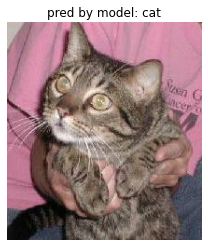

In [125]:
## Example pred

mini_pred = np.round(model.predict(test_generator[0]))
class_names={1:'dog',0:'cat'}

image=tf.keras.preprocessing.image.load_img('./test1/'+list_test_dir[0])
plt.imshow(image)
plt.title(f'pred by model: {class_names[mini_pred.reshape(-1)[0]]}')
plt.axis('off')
plt.show()